In [1]:
!pip install -U transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 85.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 553.3/553.3 kB 37.9 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface-hub 0.36.0
    Uninstalling huggingface-hub-0.36.0:
      Successfully uninstalled huggingface-hub-0.36.0
  Attempting uninstall: transformers
    Found existing installation: transformers 4.57.1
    Uninstalling transformers-4.57.1:
      Successfully uninstalled transformers-4.57.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.1.1 requires transformers<5.0.0,>=4.41.0, but you have transformers 5.2.0 which is incompatible.
gradio 5.49.1 requires pydantic<2.12,>=2.0, but you have pydantic 2.12.5 which is incompatible.


In [2]:
import torch
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM


In [3]:
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

MODEL_NAME = "redrussianarmy/gpt2-turkish-cased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()


config.json:   0%|          | 0.00/720 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/595 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/357 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/510M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie transformer.wte.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
GPT2LMHeadModel LOAD REPORT from: redrussianarmy/gpt2-turkish-cased
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/510M [00:00<?, ?B/s]

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [4]:
def generate_texts(prompt, config, n=5, max_tokens=20):
    input_ids = tokenizer(prompt, return_tensors="pt").input_ids.to(device)

    outputs = model.generate(
        input_ids=input_ids,
        max_new_tokens=max_tokens,
        do_sample=True,
        temperature=config["temperature"],
        top_k=config["top_k"],
        top_p=config["top_p"],
        num_return_sequences=n,
        pad_token_id=tokenizer.eos_token_id
    )

    return [tokenizer.decode(o, skip_special_tokens=True) for o in outputs]


In [5]:
def distinct_n(texts, n=1):
    tokens = []
    for t in texts:
        words = t.split()
        tokens.extend([tuple(words[i:i+n]) for i in range(len(words)-n+1)])
    return len(set(tokens)) / max(len(tokens), 1)


In [6]:
sampling_configs = {
    "Temp_0.7": {"temperature": 0.7, "top_k": 50, "top_p": 0.9},
    "Temp_1.0": {"temperature": 1.0, "top_k": 50, "top_p": 0.9},
    "Temp_1.3": {"temperature": 1.3, "top_k": 50, "top_p": 0.9},
    "TopP_0.8": {"temperature": 1.0, "top_k": 50, "top_p": 0.8},
    "TopP_0.95": {"temperature": 1.0, "top_k": 50, "top_p": 0.95},
}


In [7]:
prompts = [
    "Yapay zeka gelecekte",
    "Bu çalışmada önerilen yöntem",
    "Türkiye'de teknoloji alanında",
    "Makine öğrenmesi modelleri"
]


In [8]:
results = []

for name, config in sampling_configs.items():
    for prompt in prompts:
        texts = generate_texts(prompt, config, n=5)

        results.append({
            "Sampling": name,
            "Prompt": prompt,
            "Avg_Length": np.mean([len(t.split()) for t in texts]),
            "Distinct-1": distinct_n(texts, 1),
            "Distinct-2": distinct_n(texts, 2),
            "Example": texts[0]
        })

df = pd.DataFrame(results)
df


,Sampling,Prompt,Avg_Length,Distinct-1,Distinct-2,Example
0,Temp_0.7,Yapay zeka gelecekte,20.2,0.594059,0.781250,Yapay zeka gelecekte bu tür konulara ağırlık v...
1,Temp_0.7,Bu çalışmada önerilen yöntem,20.2,0.495050,0.729167,"Bu çalışmada önerilen yöntem, bir hastanın bir..."
2,Temp_0.7,Türkiye'de teknoloji alanında,18.8,0.531915,0.707865,Türkiye'de teknoloji alanında faaliyet göstere...
3,Temp_0.7,Makine öğrenmesi modelleri,17.4,0.310345,0.475610,"Makine öğrenmesi modelleri, CNC makine öğrenme..."
4,Temp_1.0,Yapay zeka gelecekte,17.2,0.639535,0.827160,Yapay zeka gelecekte geleceğin insanında nasıl...
5,Temp_1.0,Bu çalışmada önerilen yöntem,18.6,0.645161,0.840909,"Bu çalışmada önerilen yöntemlerin arasında, uy..."
6,Temp_1.0,Türkiye'de teknoloji alanında,17.0,0.741176,0.887500,Türkiye'de teknoloji alanında yeni bir sayfa a...
7,Temp_1.0,Makine öğrenmesi modelleri,15.8,0.772152,0.905405,"Makine öğrenmesi modelleri, bilgisayar öğrenme..."
8,Temp_1.3,Yapay zeka gelecekte,18.4,0.663043,0.839080,Yapay zeka gelecekte de devam edecek ve bu yüz...
9,Temp_1.3,Bu çalışmada önerilen yöntem,17.2,0.755814,0.876543,"Bu çalışmada önerilen yöntem, her 3-5 gün içer..."


In [9]:
stat_summary = df.groupby("Sampling")[[
    "Distinct-1", "Distinct-2", "Avg_Length"
]].agg(["mean", "std"]).round(3)

print(stat_summary)


          Distinct-1        Distinct-2        Avg_Length       
                mean    std       mean    std       mean    std
Sampling                                                       
Temp_0.7       0.483  0.122      0.673  0.135      19.15  1.340
Temp_1.0       0.700  0.067      0.865  0.037      17.15  1.147
Temp_1.3       0.726  0.059      0.880  0.030      18.05  0.574
TopP_0.8       0.624  0.071      0.820  0.078      18.95  0.823
TopP_0.95      0.733  0.059      0.890  0.026      17.30  1.039


In [10]:
human_eval_df = df[["Sampling", "Prompt", "Example"]].copy()

human_eval_df["Fluency"] = np.nan
human_eval_df["Coherence"] = np.nan
human_eval_df["Meaningfulness"] = np.nan

human_eval_df.to_csv("human_evaluation_form.csv", index=False)


In [11]:
human_results = pd.read_csv("human_evaluation_form.csv")

human_summary = human_results.groupby("Sampling")[[
    "Fluency", "Coherence", "Meaningfulness"
]].mean().round(2)

print(human_summary)


           Fluency  Coherence  Meaningfulness
Sampling                                     
Temp_0.7       NaN        NaN             NaN
Temp_1.0       NaN        NaN             NaN
Temp_1.3       NaN        NaN             NaN
TopP_0.8       NaN        NaN             NaN
TopP_0.95      NaN        NaN             NaN


In [12]:
import os

os.listdir("/kaggle/input")


['human-evaluation-form']

In [13]:
os.listdir("/kaggle/input/human-evaluation-form")


['human_evaluation_form.xlsx']

In [14]:
import pandas as pd

# 1️⃣ Dosya yolu (tek ve net)
xlsx_path = "/kaggle/input/human-evaluation-form/human_evaluation_form.xlsx"

# 2️⃣ Excel dosyasını oku
human_results = pd.read_excel(xlsx_path)

# 3️⃣ Kontrol amaçlı ilk satırlar
human_results.head()
human_summary = (
    human_results
    .groupby("Sampling")[["Fluency", "Coherence", "Meaningfulness"]]
    .mean()
    .round(2)
)

human_summary
human_stats = (
    human_results
    .groupby("Sampling")[["Fluency", "Coherence", "Meaningfulness"]]
    .agg(["mean", "std"])
    .round(2)
)

human_stats


Fluency       Coherence       Meaningfulness      
             mean   std      mean   std           mean   std
Sampling                                                    
Temp_0.7     2.00  0.82      1.75  0.96           1.50  1.00
Temp_1.0     2.50  1.29      3.00  1.15           2.50  1.29
Temp_1.3     3.00  1.41      2.25  0.96           2.75  1.26
TopP_0.8     3.25  1.26      2.25  1.26           3.25  1.26
TopP_0.95    2.50  1.00      1.75  0.96           1.75  0.96

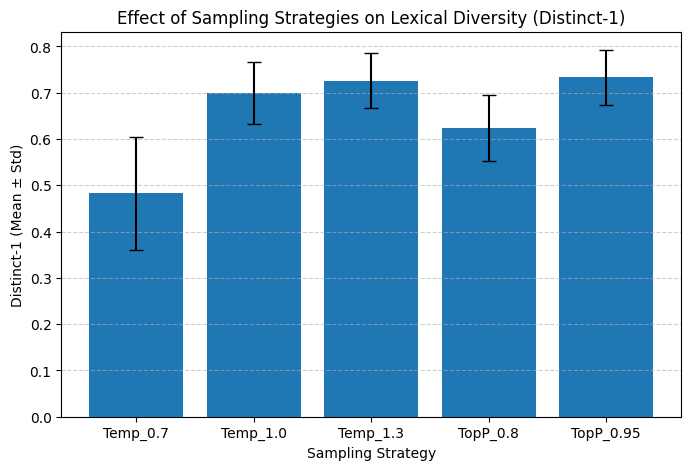

In [15]:
mean_d1 = df.groupby("Sampling")["Distinct-1"].mean()
std_d1 = df.groupby("Sampling")["Distinct-1"].std()

plt.figure(figsize=(8,5))
plt.bar(mean_d1.index, mean_d1, yerr=std_d1, capsize=5)
plt.ylabel("Distinct-1 (Mean ± Std)")
plt.xlabel("Sampling Strategy")
plt.title("Effect of Sampling Strategies on Lexical Diversity (Distinct-1)")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()


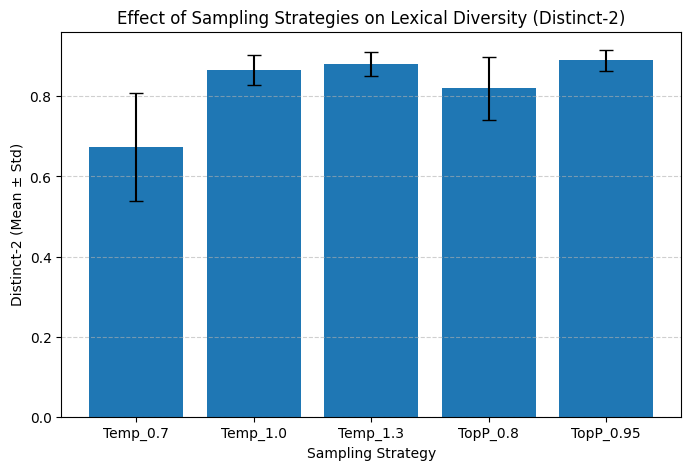

In [16]:
mean_d2 = df.groupby("Sampling")["Distinct-2"].mean()
std_d2 = df.groupby("Sampling")["Distinct-2"].std()

plt.figure(figsize=(8,5))
plt.bar(mean_d2.index, mean_d2, yerr=std_d2, capsize=5)
plt.ylabel("Distinct-2 (Mean ± Std)")
plt.xlabel("Sampling Strategy")
plt.title("Effect of Sampling Strategies on Lexical Diversity (Distinct-2)")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()


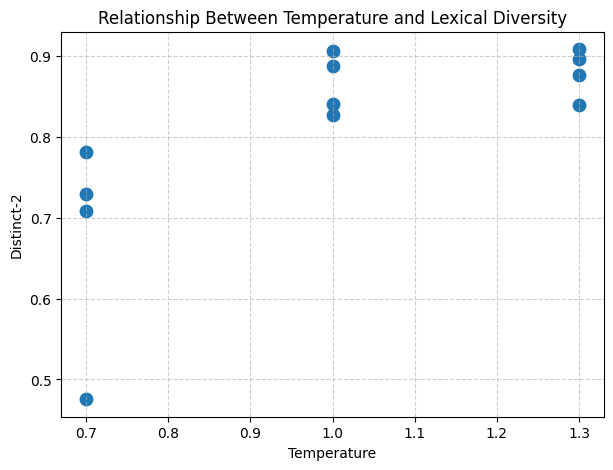

In [17]:
temp_map = {
    "Temp_0.7": 0.7,
    "Temp_1.0": 1.0,
    "Temp_1.3": 1.3
}

temp_df = df[df["Sampling"].isin(temp_map.keys())].copy()
temp_df["Temperature"] = temp_df["Sampling"].map(temp_map)

plt.figure(figsize=(7,5))
plt.scatter(temp_df["Temperature"], temp_df["Distinct-2"], s=80)

plt.xlabel("Temperature")
plt.ylabel("Distinct-2")
plt.title("Relationship Between Temperature and Lexical Diversity")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()


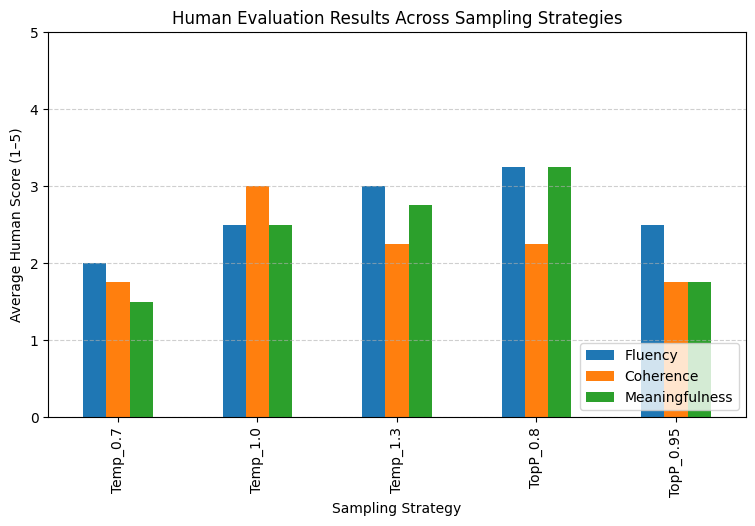

In [18]:
human_summary.plot(
    kind="bar",
    figsize=(9,5)
)

plt.ylabel("Average Human Score (1–5)")
plt.xlabel("Sampling Strategy")
plt.title("Human Evaluation Results Across Sampling Strategies")
plt.ylim(0,5)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.legend(loc="lower right")
plt.show()


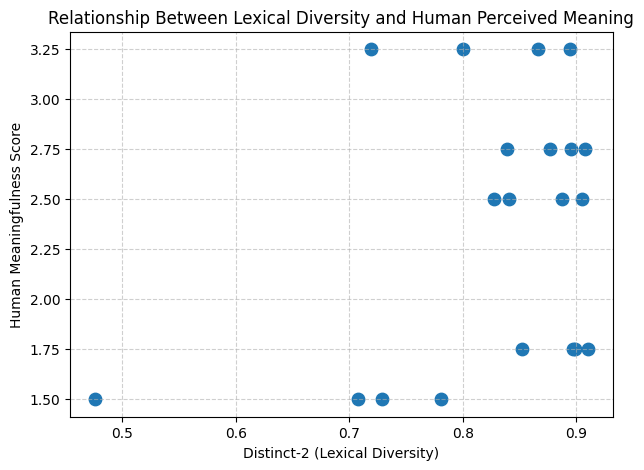

In [19]:
merged = df.merge(
    human_summary,
    left_on="Sampling",
    right_index=True
)

plt.figure(figsize=(7,5))
plt.scatter(
    merged["Distinct-2"],
    merged["Meaningfulness"],
    s=80
)

plt.xlabel("Distinct-2 (Lexical Diversity)")
plt.ylabel("Human Meaningfulness Score")
plt.title("Relationship Between Lexical Diversity and Human Perceived Meaning")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()


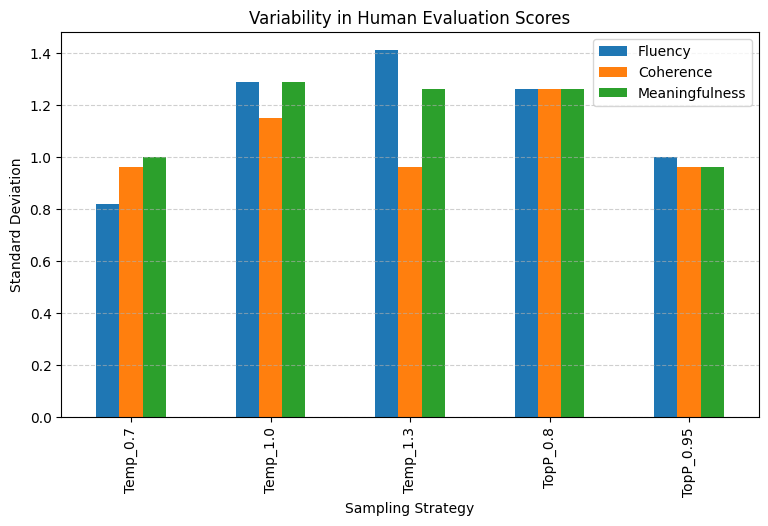

In [20]:
std_df = human_stats.xs("std", level=1, axis=1)

std_df.plot(
    kind="bar",
    figsize=(9,5)
)

plt.ylabel("Standard Deviation")
plt.xlabel("Sampling Strategy")
plt.title("Variability in Human Evaluation Scores")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()
